In [1]:
from lib import epl 
from lib import OSN
from lib import readout
from lib import plots
import numpy as np
import pickle 
import time
import random #remember to do this in class
from sklearn import datasets
import matplotlib.pyplot as plt
from preprocess import preprocessing as pre
import epl.src.computeResults as compResults
from numpy.matlib import repmat
#import epl.src.multi_pattern_learning.epl_multi_pattern_learning 
#from epl.src.multi_pattern_learning.epl_multi_pattern_learning import EPLMultiPatternLearning

from sklearn.decomposition import PCA


LOAD AND GENERATE DATA


In [2]:
# load the digits dataset which consists of 8X8 images of digits
digits = datasets.load_digits() #refer to when plotting

# project the 64-dimensional data to a lower dimension
pca = PCA(n_components=64, whiten=False)
pca.fit(digits.data) #refer to whe
#may use digits.data

images = digits.images
c_images = pca.transform(digits.data) #I changed from digits.images to digits.data

#compare with c_images = digits.data

#from 2 by 2 to 1d arrays (if 2 by 2)
targets = digits.target #need to reshape images and targets
#may need to make c_images into an array

# create a map of {digt->list of images of the digits}
image_dict = {n : [] for n in range(10)}
for t, img in zip(targets, c_images):
    image_dict[t].append(img)

In [3]:
c_images.shape

(1797L, 64L)

In [4]:
digits.images.shape

(1797L, 8L, 8L)

In [5]:
digits.data.shape

(1797L, 64L)

In [6]:

numPatterns = 6
#randomly choose 6 digits
digits = np.array([0, 2, 4, 5, 7, 9], ndmin = 2)


In [7]:
#CAN STAY IN CODE

#define utility functions
#create the training dataset by choosing the appropriate images of the digts to be learned
def get_training_data(digits, image_dict, fourX=True, idx=0):
    train_data = []
    for digit in digits:
        training_image = image_dict[digit][idx]
        print(training_image)
        training_image = np.ndarray.astype(training_image, int)
        if fourX: training_image = (training_image//4)*4
        training_image = np.ndarray.flatten(training_image).tolist()
        print(training_image)
        train_data.append(training_image)
    return train_data

In [8]:
# generate the training data
digitss = [0, 2, 4, 5, 7, 9]
train_data = np.array(get_training_data(digits=digitss, image_dict = image_dict))

[-1.25946645e+00  2.12748835e+01 -9.46305462e+00  1.30141887e+01
 -7.12882278e+00 -7.44065876e+00  3.25283716e+00  2.55347036e+00
 -5.81842142e-01  3.62569695e+00  2.58595688e+00  1.55160708e+00
  8.54496709e-01 -3.33874935e+00  5.90658968e+00  2.74359339e+00
  4.19836907e-01 -8.98149693e-01  7.02610866e-01 -3.46211868e+00
  2.68084958e+00  1.00944951e+00  2.00970276e+00  1.29531479e+00
  1.17887873e+00  2.30058185e+00  3.67072108e+00 -9.43668900e-01
 -1.13250195e+00  2.35979550e+00 -1.81738593e+00 -7.55016284e-01
  1.62841809e-01 -2.11297739e+00  1.09482318e+00  1.95685532e-01
 -8.99936129e-02 -2.76374068e+00  1.08888322e+00  2.06004009e-01
  1.70451133e+00  5.81318379e-01  7.12698392e-01 -1.88038868e-01
  6.28313404e-01 -5.94986903e-01  4.76923307e-02 -7.13294070e-01
 -3.39315207e-01  4.30994090e-02 -4.21401144e-01 -1.21887592e-01
 -6.33281370e-02 -5.70236060e-02 -4.87854310e-02 -1.81625690e-03
  1.11015905e-02 -1.54744844e-03  8.24746988e-03  2.14808613e-03
  1.04388936e-03  1.08468

In [9]:
def generateTestingData(trainingData, occlusionPercent, numTestSamples,
                        sensorDynamicRange=16):  #15 to 16
    """ generate synthetic testing data for EPL network"""
    data = trainingData
    p = occlusionPercent
    n = numTestSamples
    occludedData = []
    nsensors = len(data[0])

    for i in range(0, len(data)):
        ndim = len(data[i])  # dimension of data
        for j in range(0, n):
            occludedData.append([])
            affected_ids = random.sample(range(ndim), int(p * ndim))
            for k in range(0, ndim):
                if k in affected_ids:
                    occludedData[i * n + j].append(
                        random.randint(0, sensorDynamicRange))
                else:
                    occludedData[i * n + j].append(data[i][k])
    return occludedData
numTestSamples = 5
occlusionPercent = 0.2 # randomly perturb only 20% of the image pixels
test_data = np.array(generateTestingData(trainingData=train_data,
                                occlusionPercent=occlusionPercent,
                                numTestSamples=numTestSamples))

# plot train_data and test_data

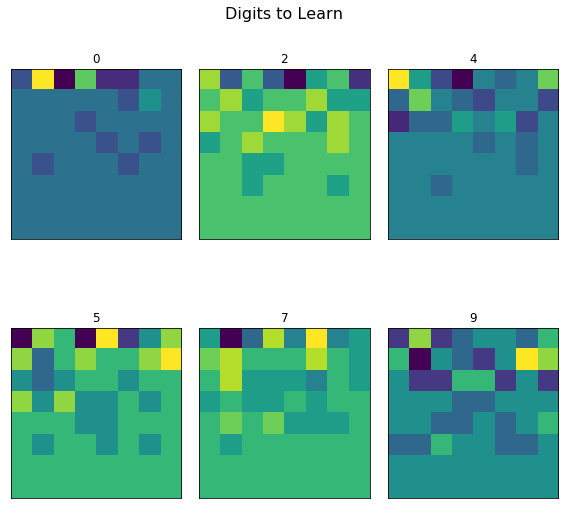

In [10]:
# Train Data
pre.plot_images(digitss, train_data, title="Digits to Learn")

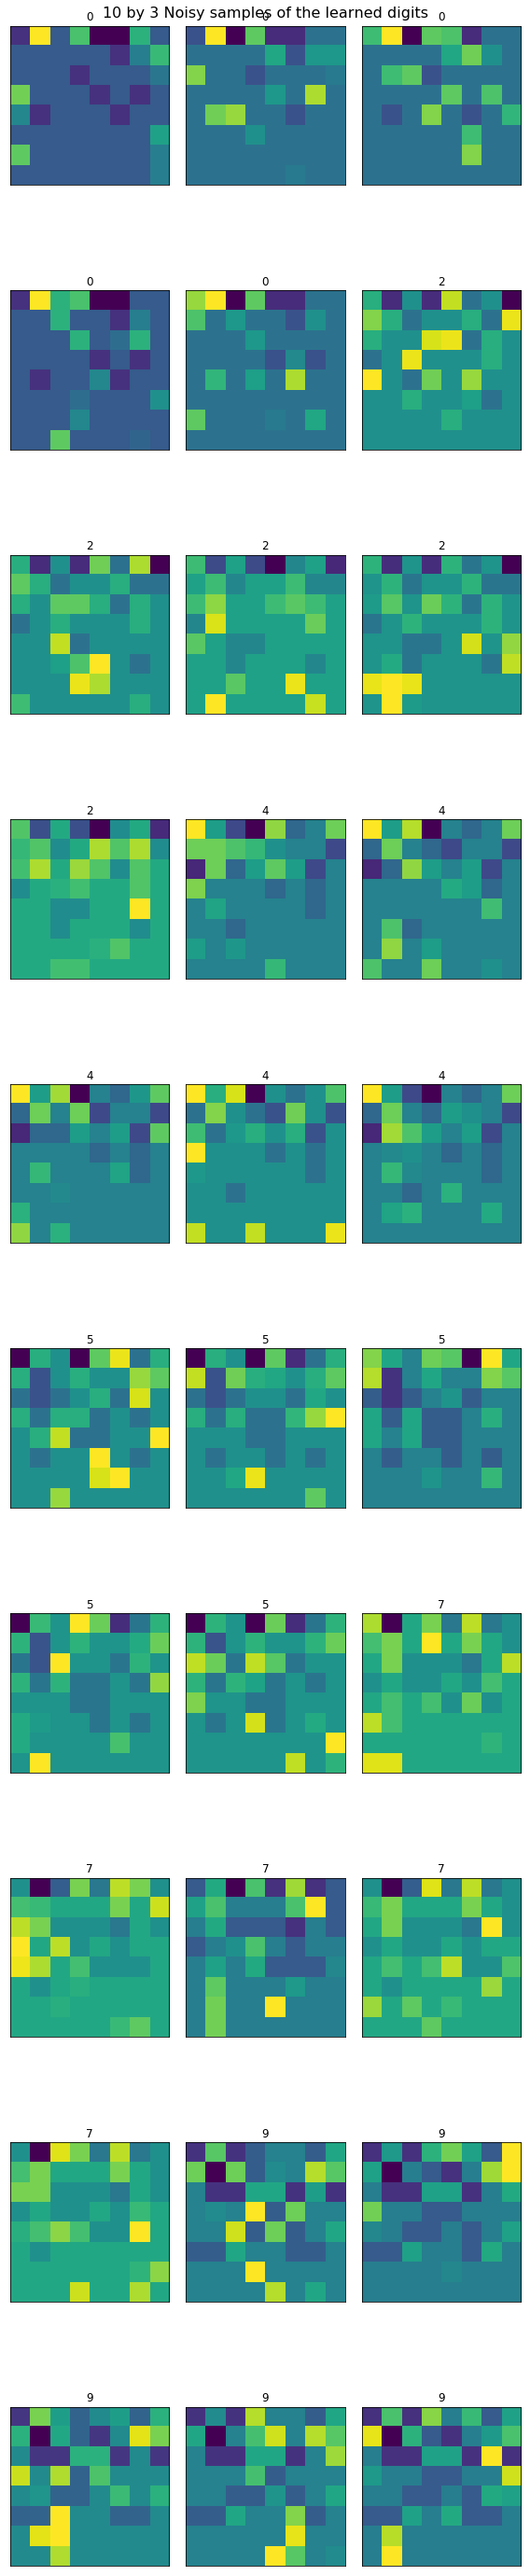

In [11]:
"""
Test Data:

can have 10 rows instead of 2 to show all of test_data
"""
test_digits = repmat(digitss, numTestSamples,1).T.reshape((1,-1))
test_digitss = repmat(digits, numTestSamples,1).T.flatten()
pre.plot_images(test_digitss, test_data, title="10 by 3 Noisy samples of the learned digits",nrows=10, ncols=3)
#pre.plot_images(digits, test_data, title="2 by 3 Noisy samples of the learned digits",nrows=2, ncols=3)

# scaling and defining trainingOdors and testOdors

In [12]:
scale = 15.0
# use preprocessing function
# scaling is fine

train_data -= train_data.min()
train_data = train_data*(scale/train_data.max())
trainingOdors = train_data.astype(np.int64)

test_data -= test_data.min()
test_data = test_data* scale/test_data.max()
testOdors = test_data.astype(np.int64)

## training and testing

In [13]:
from lib import epl
nGamma = 5
nOdors = len(trainingOdors); 
nTestPerOdor = len(testOdors)/nOdors;  
nGammaPerOdor = 5
print("Number of odors to train = " + str(len(trainingOdors))); 
print("Number of odors to test = " + str(len(testOdors))); 

#Network initialization
nMCs = len(trainingOdors[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training
t1 = time.time(); 
for i in range(0, len(trainingOdors)):
    print("Training odor " + str(i+1)) 
    sniff(trainingOdors[i], learn_flag=1,nGammaPerOdor = 10); #nGammaPerOdor_training = 10 define early in code
    # changed nGammaPerOdor from 5 to 10
    epl.GClayer.invokeNeurogenesis();
#added this for loop to change structure of epl.gammaCode
for i in range(0, len(trainingOdors)):
    sniff(trainingOdors[i], learn_flag=0, nGammaPerOdor = nGammaPerOdor);
    
#Testing
for i in range(0, len(testOdors)):
    sniff(testOdors[i], learn_flag=0, nGammaPerOdor = nGammaPerOdor); 
    if((i+1)%10==0 and (i+1)!=0):
        print(str(i+1) + " odors tested"); 
t2 = time.time(); 
print("Simulation Duration = " + str(t2-t1) + "s")


Number of odors to train = 6
Number of odors to test = 30
Training odor 1
Training odor 2
Training odor 3
Training odor 4
Training odor 5
Training odor 6
10 odors tested
20 odors tested
30 odors tested
Simulation Duration = 308.065999985s


## epl gammaCode parsing


In [14]:
nGammaPerOdor_training = 10
#Remember the first training loop uses nGammaPerOdor = 10
#The added 5 refers to the second loop of training which uses the default variable in sniff for nGammaPerOdor
#The added len(testOdors) * 5 refers to the third testing loop which uses the dafault variable in sniff for nGammaPerOdor
# len(testOdors) = len(digits) * numTestSamples because generateTestOdors generates 5 noisy versions of each test digit
# this is in order of loops
gammaCode_size = len(trainingOdors)*(nGammaPerOdor_training + nGammaPerOdor) + digits.size* numTestSamples * nGammaPerOdor
#digits.size=len(trainingOdors) should have numTrainingSamples
#rename numTestSamples to numPerturbedSamples
(gammaCode_size,len(epl.gammaCode))

(240, 240)

In [15]:
numTestSamples

5

In [16]:
len(epl.gammaCode[0])

64

In [17]:
len(epl.gammaCode)

240

In [18]:
testOdors.shape

(30L, 64L)

In [19]:
trainingOdors.shape

(6L, 64L)

In [20]:

trained = np.array(epl.gammaCode[len(trainingOdors)*10:len(trainingOdors)*15]).reshape(nGammaPerOdor, 6, -1)
tested = np.array(epl.gammaCode[len(trainingOdors)*15:]).reshape(nGammaPerOdor, 30, -1)

In [21]:
trained[0][0]==trained[0][5]

array([False, False, False, False, False, False,  True, False,  True,
       False, False,  True,  True, False, False, False, False,  True,
        True, False, False, False, False,  True, False,  True, False,
        True, False,  True, False,  True,  True, False, False, False,
        True, False,  True,  True,  True,  True, False,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

In [22]:
len(testOdors)/nGammaPerOdor

6

In [23]:
trained.shape

(5L, 6L, 64L)

In [24]:
tested.shape #tested[-1]

(5L, 30L, 64L)

In [25]:
# jaccardSimilarity(trained[-1,i], tested[-1,j])
# i is the consecutive original digit. j is the consecutive test digit
# make an array from nested loop
def jaccardSimilarity(l1=[], l2=[]):
    """ computes Jaccard similarity"""
    list1 = []
    list2 = []
    for i in range(0, len(l1)):
        list1.append((i, l1[i]))
        list2.append((i, l2[i]))
    set1 = set(list1)
    set2 = set(list2)
    intersectionSize = len(set.intersection(set1, set2))
    unionSize = len(set.union(set1, set2))
    # print intersectionSize, unionSize;
    return round(intersectionSize/float(unionSize), 4)
def computeSimilarity(l1, l2):
    """ computes similarity index """
    return jaccardSimilarity(l1, l2)

In [26]:

true_negative = 0
false_positive = 0


SImatrix = np.zeros((len(digits[0]), len(test_digits[0])), dtype =float)  
for i in range(0, len(trained[-1])):
    for j in range(0, len(tested[-1])):
        SImatrix[i][j] = (computeSimilarity(trained[-1][i], tested[-1][j]))
        
        """
        if SImatrix[i][j]> 0.75: #and test_digits[sim_index] == test_digits[i*5]: 
            true_positive+=1
        elif SImatrix[i][j]< 0.75: #and test_digits[sim_index] == test_digits[i*5]:
            false_negative+=1
        elif SImatrix[i][j] < 0.75: #and test_digits[sim_index] != test_digits[i*5]:
            true_negative+=1
        elif SImatrix[i][j] > 0.75: #and test_digits[sim_index] != test_digits[i*5]:
            false_positive+=1
        else:
            print("error")
#target recognition matrix to find what is above and below .75 
true_positive, true_negative, false_positive, false_negative
"""
decisionMatrix = (SImatrix> 0.75)

In [27]:
SImatrix

array([[0.4545, 0.7778, 0.9394, 0.9394, 0.9692, 0.3333, 0.6842, 0.8824,
        0.9394, 0.9394, 0.4545, 0.8286, 0.9104, 0.9692, 0.9692, 0.3333,
        0.7534, 0.9104, 0.9692, 0.9692, 0.3913, 0.8551, 0.8824, 0.9394,
        0.9394, 0.3196, 0.8028, 0.9104, 0.9692, 0.9692],
       [0.2549, 0.4222, 0.4222, 0.4382, 0.4382, 0.7067, 0.5422, 0.4713,
        0.4545, 0.4545, 0.7534, 0.5238, 0.4884, 0.4713, 0.4713, 0.7297,
        0.5802, 0.4884, 0.4713, 0.4713, 0.7297, 0.5422, 0.4713, 0.4545,
        0.4545, 0.6842, 0.5238, 0.4884, 0.4713, 0.4713],
       [0.4222, 0.7067, 0.8028, 0.8028, 0.8286, 0.3913, 0.8028, 0.8551,
        0.8551, 0.8551, 0.5059, 0.9692, 0.8824, 0.8824, 0.8824, 0.3913,
        0.8824, 0.8824, 0.8824, 0.8824, 0.4545, 0.9394, 0.8551, 0.8551,
        0.8551, 0.3763, 0.8551, 0.8824, 0.8824, 0.8824],
       [0.4382, 0.7534, 0.8551, 0.9104, 0.8824, 0.3617, 0.7067, 0.9692,
        0.9104, 0.9104, 0.4884, 0.8551, 1.    , 0.9394, 0.9394, 0.3617,
        0.7778, 1.    , 0.9394, 0.939

In [28]:
decisionMatrix 

array([[False,  True,  True,  True,  True, False, False,  True,  True,
         True, False,  True,  True,  True,  True, False,  True,  True,
         True,  True, False,  True,  True,  True,  True, False,  True,
         True,  True,  True],
       [False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False,  True,  True,  True, False,  True,  True,  True,
         True, False,  True,  True,  True,  True, False,  True,  True,
         True,  True, False,  True,  True,  True,  True, False,  True,
         True,  True,  True],
       [False,  True,  True,  True,  True, False, False,  True,  True,
         True, False,  True,  True,  True,  True, False,  True,  True,
         True,  True, False,  True,  True,  True,  True, False,  True,
         True,  True,  True],
       [False,  True,  True,

In [29]:
truthMatrix = np.equal(digits.T, test_digits)
truthMatrix.shape
#digits which is a 2d array, use reshape to 
#operations broadcasting when comparing two arrays of different dimensions

(6L, 30L)

In [30]:
#this is not decisionMatrix xor truthMatrix
#returns all the places where the decision is correct (trues are trues and falses re false)
#take a look at this logic
# Try this alternative expression: correct = not (decisionMatrix xor truthMatrix)
correct = ~(decisionMatrix ^ truthMatrix)

In [31]:
correctID = np.count_nonzero(correct)
per_correct = float(correctID)/SImatrix.size *100

In [32]:
per_correct

41.11111111111111

In [33]:
repmat(digits, len(test_digits)-1)

TypeError: repmat() takes exactly 3 arguments (2 given)

In [ ]:
SImatrix.size

In [ ]:
pre.plotFigure3b(SImatrix, epl.nMCs, nGamma=5,figsize = (3,12))